In [ ]:
!pip install --quiet ONE-api

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.8 MB/s eta 0:00:00
Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [ ]:
sessions_info = one.alyx.rest('sessions', 'list', tag='2021_Q1_IBL_et_al_Behaviour', order='-start_time')
print("Total sessions found:", len(sessions_info))

/usr/local/lib/python3.12/dist-packages/one/webclient.py:1551: UserWarning: Error: Unsupported fields '{'order'}' in query parameters for endpoint sessions.
  warnings.warn(


Total sessions found: 6488


In [ ]:
mouse_dict = {}
for session in sessions_info:
    mouse_id = session['subject']
    eid = session['id']
    if mouse_id not in mouse_dict:
        mouse_dict[mouse_id] = []
    mouse_dict[mouse_id].append(eid)

all_mouse_ids = list(mouse_dict.keys())
print("Number of mice found:", len(all_mouse_ids))
print("First 10 mice:", all_mouse_ids[:10])

Number of mice found: 170
First 10 mice: ['SWC_039', 'SWC_030', 'SWC_042', 'SWC_040', 'SWC_038', 'NYU-24', 'NYU-26', 'NYU-25', 'CSH_ZAD_011', 'SWC_041']


Ill update the dictionary and include everything

In [ ]:
mouse_trials = {}
for mouse_id, eids in mouse_dict.items():
    eid = eids[0]  # most recent session
    trials = one.load_object(eid, 'trials')
    mouse_trials[mouse_id] = trials.to_df()

print("Loaded trials for", len(mouse_trials), "mice")
print(mouse_trials[all_mouse_ids[0]].columns.tolist())

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_039/2020-03-23/001/alf/_ibl_trials.repNum.npy: 100%|██████████| 8.83k/8.83k [00:00<00:00, 41.9kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_039/2020-03-23/001/alf/_ibl_trials.table.pqt: 100%|██████████| 82.8k/82.8k [00:00<00:00, 234kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_030/2020-03-23/001/alf/_ibl_trials.table.pqt: 100%|██████████| 58.8k/58.8k [00:00<00:00, 214kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/hoferlab/Subjects/SWC_042/2020-03-23/001/alf/_ibl_trials.table.pqt: 100%|██████████| 84.6k/84.6k [00:00<00:00, 255kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/hoferlab/Subjects/SWC_042/2020-03-23/001/alf/_ibl_trials.repNum.npy: 100%|██████████| 9.02k/9.02k [00:00<00:00, 43.3kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Sub

Loaded trials for 170 mice
['repNum', 'response_times', 'goCue_times', 'stimOn_times', 'choice', 'probabilityLeft', 'firstMovement_times', 'feedbackType', 'feedback_times', 'contrastRight', 'rewardVolume', 'contrastLeft', 'intervals_0', 'intervals_1']


In [ ]:
trial_counts = [len(df) for df in mouse_trials.values()]

print("Minimum trials:", min(trial_counts))
print("Maximum trials:", max(trial_counts))
print("Average trials:", sum(trial_counts) / len(trial_counts))

Minimum trials: 12
Maximum trials: 1229
Average trials: 594.3882352941176


Now it becomes:

"Does a mouse's decision strategy change from the beginning to the end of a session?"

This is easier to defend statistically because each regression uses hundreds of trials instead of ~30–40.

New Project Outline
Research Question

Does the decision strategy of mice change over the course of a behavioral session?

Instead of estimating β from many very small windows, compare the Early and Late parts of each session.

In [ ]:
sample_id = all_mouse_ids[0]
sample_df = mouse_trials[sample_id]

print(sample_df.shape)
print(sample_df.dtypes)
print(sample_df.isnull().sum())
sample_df.head()

(1088, 14)
repNum                   int64
response_times         float64
goCue_times            float64
stimOn_times           float64
choice                 float64
probabilityLeft        float64
firstMovement_times    float64
feedbackType           float64
feedback_times         float64
contrastRight          float64
rewardVolume           float64
contrastLeft           float64
intervals_0            float64
intervals_1            float64
dtype: object
repNum                   0
response_times           0
goCue_times              0
stimOn_times             0
choice                   0
probabilityLeft          0
firstMovement_times     11
feedbackType             0
feedback_times           0
contrastRight          569
rewardVolume             0
contrastLeft           519
intervals_0              0
intervals_1              0
dtype: int64


,repNum,response_times,goCue_times,stimOn_times,choice,probabilityLeft,firstMovement_times,feedbackType,feedback_times,contrastRight,rewardVolume,contrastLeft,intervals_0,intervals_1
0,0,8.0617,4.8785,4.8606,1.0,0.5,4.909209,-1.0,8.0919,1.0000,0.0,NaN,0.0000,10.642003
1,1,13.1908,12.9255,12.8949,-1.0,0.9,12.990209,1.0,13.1909,1.0000,1.5,NaN,11.0787,14.741803
2,0,17.5382,17.2550,17.2279,1.0,0.5,17.294209,1.0,17.5383,NaN,1.5,1.0,15.0831,19.108003
3,0,20.3979,20.1284,20.0942,-1.0,0.5,20.269209,1.0,20.3980,0.2500,1.5,NaN,19.4524,21.974703
4,0,26.2016,24.4939,24.4610,-1.0,0.5,25.755209,1.0,26.2017,0.0625,1.5,NaN,22.3009,27.774803


In [ ]:
# signed contrast by subtracting contrastLeft from contrastRight
def clean_trials(d):
    d = d[d['choice'].isin([-1, 1])].copy()

    d['contrastLeft'] = d['contrastLeft'].fillna(0.0)
    d['contrastRight'] = d['contrastRight'].fillna(0.0)

    # IBL signed contrast
    d['signed_contrast'] = d['contrastRight'] - d['contrastLeft']

    # z-score signed contrast (recommended in Ashwood et al.)
    d['signed_contrast_z'] = (
        d['signed_contrast'] - d['signed_contrast'].mean()
    ) / d['signed_contrast'].std()

    # IMPORTANT:
    # Keep this unless your choice coding is reversed
    d['y'] = (d['choice'] == -1).astype(int)

    return d[['signed_contrast', 'signed_contrast_z', 'y']]

# quick test on one mouse
test_clean = clean_trials(mouse_trials['SWC_039'])
print(test_clean.shape)
test_clean.head()

(1087, 3)


,signed_contrast,signed_contrast_z,y
0,1.0000,2.045188,0
1,1.0000,2.045188,1
2,-1.0000,-1.967889,0
3,0.2500,0.540284,1
4,0.0625,0.164058,1


In [ ]:
mouse_trials['SWC_039']['choice'].value_counts()

,count
choice,
-1.0,802
1.0,285
0.0,1


In [ ]:
for mouse_id in all_mouse_ids[:5]:
    d = mouse_trials[mouse_id]
    print(mouse_id, "trials:", len(d),
          "| choice values:", d['choice'].unique(),
          "| contrast NaN pattern:", d['contrastLeft'].isnull().sum(), d['contrastRight'].isnull().sum())

SWC_039 trials: 1088 | choice values: [ 1. -1.  0.] | contrast NaN pattern: 519 569
SWC_030 trials: 739 | choice values: [ 1. -1.] | contrast NaN pattern: 408 331
SWC_042 trials: 1111 | choice values: [ 1. -1.] | contrast NaN pattern: 536 575
SWC_040 trials: 595 | choice values: [ 1. -1.] | contrast NaN pattern: 296 299
SWC_038 trials: 1000 | choice values: [ 1. -1.] | contrast NaN pattern: 490 510


In [ ]:
#attaching lab info. ( lab info still excists)

mouse_to_lab = {}
for session in sessions_info:
    mouse_id = session['subject']
    lab = session['lab']
    if mouse_id not in mouse_to_lab:
        mouse_to_lab[mouse_id] = lab

print("Mice with lab info:", len(mouse_to_lab))
print(list(mouse_to_lab.items())[:5])

Mice with lab info: 170
[('SWC_039', 'mrsicflogellab'), ('SWC_030', 'mrsicflogellab'), ('SWC_042', 'hoferlab'), ('SWC_040', 'mrsicflogellab'), ('SWC_038', 'mrsicflogellab')]


In [ ]:
MIN_TRIALS = 200  #flittering the mouse who have 200 plus trials

filtered_mouse_trials = {
    mouse: df
    for mouse, df in mouse_trials.items()
    if len(df) >= MIN_TRIALS
}

print(f"{len(filtered_mouse_trials)} mice retained")

153 mice retained


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

def plot_psychometric_section(section_df, model_name="", ax=None):
    d = section_df
    X = d["signed_contrast"].values.reshape(-1, 1)
    y = d["y"].values

    model = LogisticRegression()
    model.fit(X, y)

    x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    p = model.predict_proba(x_plot)[:, 1]

    grouped = (
        pd.DataFrame({"contrast": X.flatten(), "choice": y})
        .groupby("contrast")
        .choice
        .mean()
        .reset_index()
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(x_plot, p, color="steelblue", linewidth=2, label=model_name)
    ax.scatter(grouped["contrast"], grouped["choice"], color="black", zorder=3)
    ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
    ax.axvline(0, color="grey", linestyle="--", alpha=0.5)
    ax.set_xlabel("Signed contrast")
    ax.set_ylabel("P(choice = right)")
    ax.set_title(model_name)
    ax.set_ylim(-0.05, 1.05)

    return ax

In [ ]:
list(filtered_mouse_trials.keys())

['SWC_039',
 'SWC_030',
 'SWC_042',
 'SWC_040',
 'SWC_038',
 'NYU-24',
 'NYU-26',
 'NYU-25',
 'CSH_ZAD_011',
 'SWC_041',
 'SWC_043',
 'SWC_032',
 'SWC_033',
 'SWC_029',
 'SWC_035',
 'SWC_036',
 'NYU-23',
 'CSH_ZAD_021',
 'CSH_ZAD_019',
 'CSH_ZAD_018',
 'CSH_ZAD_017',
 'CSH_ZAD_016',
 'CSH_ZAD_024',
 'CSH_ZAD_023',
 'CSH_ZAD_015',
 'ibl_witten_18',
 'ibl_witten_20',
 'ibl_witten_19',
 'ibl_witten_17',
 'NYU-21',
 'CSH_ZAD_022',
 'ibl_witten_24',
 'ibl_witten_23',
 'ibl_witten_22',
 'CSHL058',
 'ibl_witten_21',
 'CSHL060',
 'DY_009',
 'DY_008',
 'DY_013',
 'DY_015',
 'DY_012',
 'DY_014',
 'ZM_3004',
 'ZM_3003',
 'ZM_3002',
 'ZM_3001',
 'CSHL046',
 'KS021',
 'ZM_3006',
 'ZM_3005',
 'CSHL059',
 'SWC_018',
 'KS019',
 'NYU-09',
 'NYU-20',
 'CSHL045',
 'SWC_017',
 'NYU-11',
 'CSHL052',
 'NYU-14',
 'CSHL055',
 'CSHL051',
 'DY_011',
 'KS024',
 'DY_010',
 'CSHL053',
 'ZM_2241',
 'CSHL057',
 'CSHL056',
 'NYU-13',
 'CSHL047',
 'KS017',
 'SWC_015',
 'NYU-12',
 'ZM_2240',
 'SWC_028',
 'SWC_034',
 'Z

In [ ]:
def split_into_three(df):     # dividing trials into early, middle and late

    n = len(df)

    third = n // 3

    early = df.iloc[:third]

    middle = df.iloc[third:2*third]

    late = df.iloc[2*third:]

    return early, middle, late

In [ ]:
# logistic regression to one section of one mouse's data
def fit_window_torch(
        X,
        y,
        l2_lambda=0.01,
        lr=0.05,
        steps=2500
):

    X_t = torch.tensor(
        X,
        dtype=torch.float32
    ).flatten()

    y_t = torch.tensor(
        y,
        dtype=torch.float32
    ).flatten()

    beta = torch.nn.Parameter(torch.tensor(1.0))
    bias = torch.nn.Parameter(torch.tensor(0.0))

    optimizer = torch.optim.Adam(
        [beta, bias],
        lr=lr
    )

    for _ in range(steps):

        optimizer.zero_grad()

        logits = beta * X_t + bias

        p = torch.sigmoid(logits)

        p = torch.clamp(
            p,
            1e-7,
            1-1e-7
        )

        nll = -(
            y_t*torch.log(p)
            +
            (1-y_t)*torch.log(1-p)
        ).mean()

        reg = l2_lambda * (
            beta**2 + bias**2
        )

        loss = nll + reg

        loss.backward()

        optimizer.step()

    return beta.item(), bias.item()

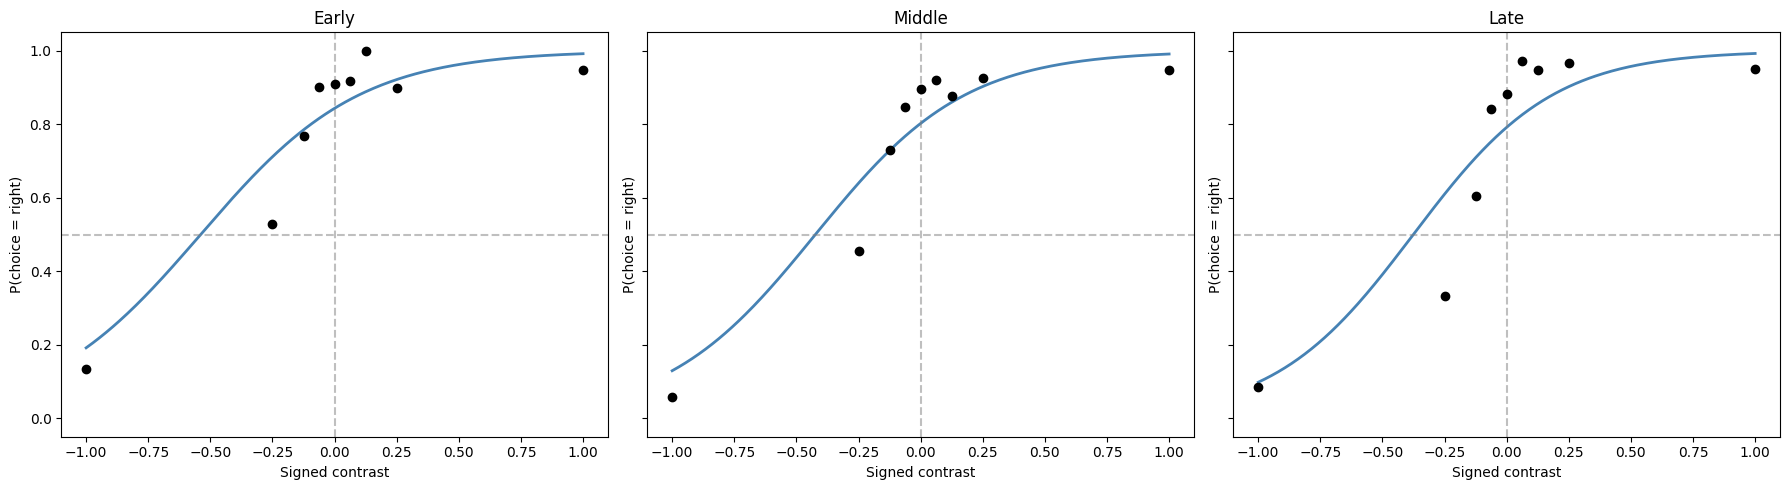

In [ ]:
sample_mouse_df = clean_trials(filtered_mouse_trials[sample_id])

early, middle, late = split_into_three(sample_mouse_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plot_psychometric_section(early, "Early", ax=axes[0])
plot_psychometric_section(middle, "Middle", ax=axes[1])
plot_psychometric_section(late, "Late", ax=axes[2])

plt.tight_layout()
plt.show()

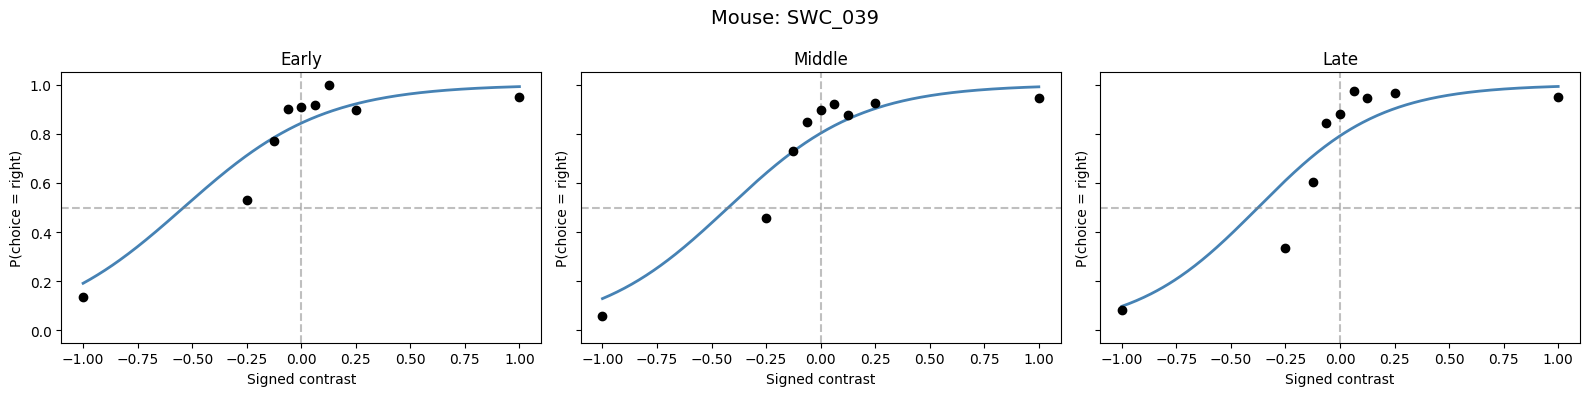

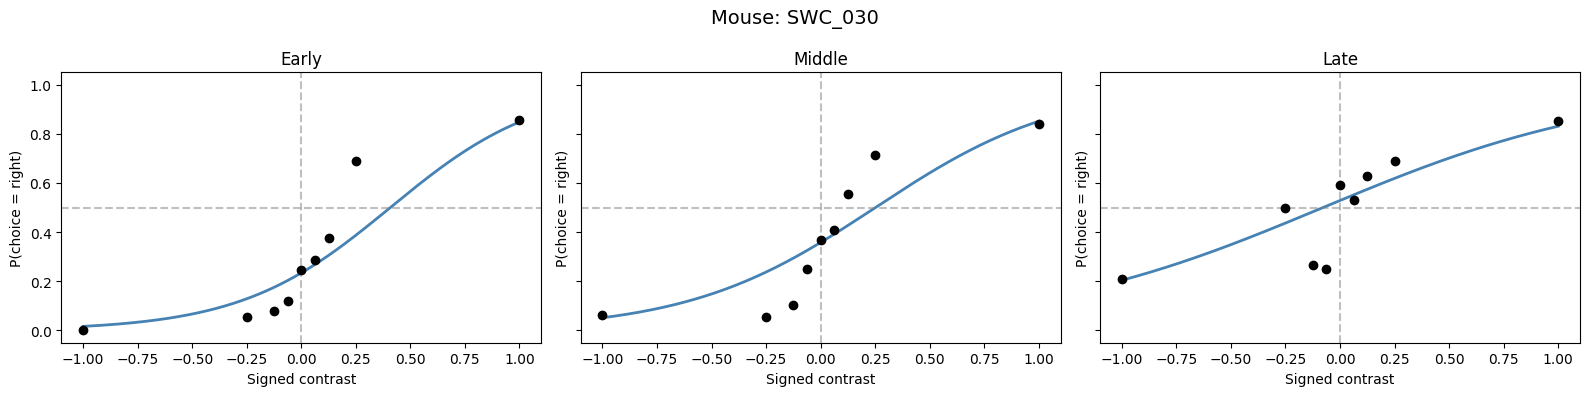

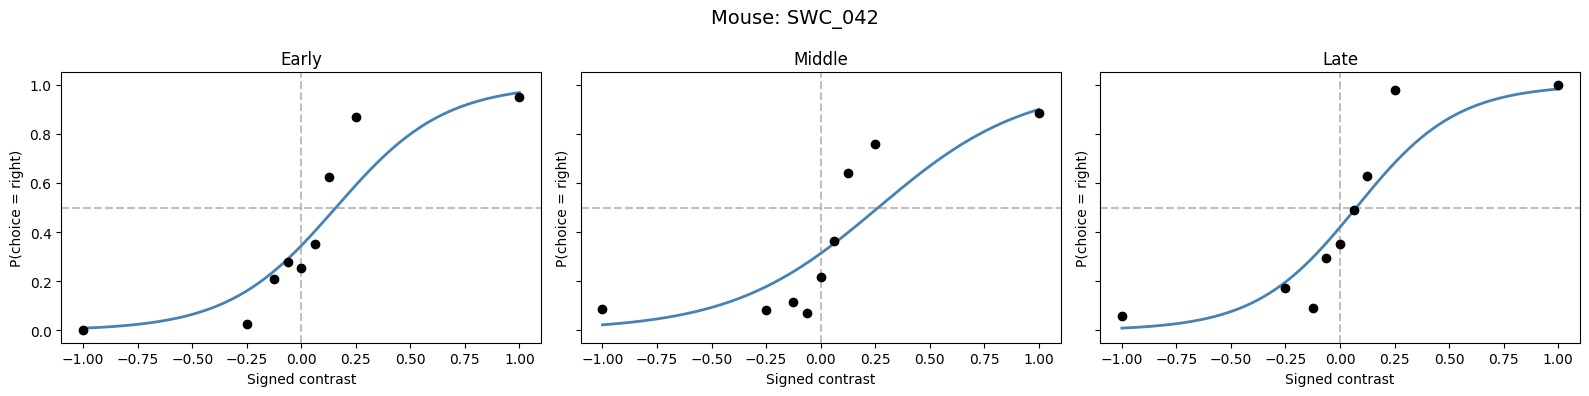

In [ ]:
example_mice = list(filtered_mouse_trials.keys())[:3]

for sample_id in example_mice:

    sample_mouse_df = clean_trials(filtered_mouse_trials[sample_id])
    early, middle, late = split_into_three(sample_mouse_df)

    fig, axes = plt.subplots(1, 3, figsize=(16,4), sharey=True)

    plot_psychometric_section(early, "Early", ax=axes[0])
    plot_psychometric_section(middle, "Middle", ax=axes[1])
    plot_psychometric_section(late, "Late", ax=axes[2])

    fig.suptitle(f"Mouse: {sample_id}", fontsize=14)

    plt.tight_layout()
    plt.show()

1. Even at the same contrast, a mouse does not always make the same choice. Internal state (attention, arousal, fatigue, motivation), previous trial history, or simple randomness all influence behavior.

2.  The black dots are averages

The black points are not individual trials


3. Stimulus contrast

to predict

Choice

But mice don't base their decisions only on contrast.

In [ ]:
def fit_three_sections(mouse_df):

    mouse_df = clean_trials(mouse_df)

    early, middle, late = split_into_three(mouse_df)

    beta_e, bias_e = fit_window_torch(
        early["signed_contrast_z"].values,
        early["y"].values
    )

    beta_m, bias_m = fit_window_torch(
        middle["signed_contrast_z"].values,
        middle["y"].values
    )

    beta_l, bias_l = fit_window_torch(
        late["signed_contrast_z"].values,
        late["y"].values
    )

    return {
        "beta_early": beta_e,
        "beta_middle": beta_m,
        "beta_late": beta_l,
        "bias_early": bias_e,
        "bias_middle": bias_m,
        "bias_late": bias_l,
    }

In [ ]:
import torch

results = []

for mouse, df in filtered_mouse_trials.items():

    params = fit_three_sections(df)

    params["mouse_id"] = mouse

    results.append(params)

results_df = pd.DataFrame(results)

results_df.head()

,beta_early,beta_middle,beta_late,bias_early,bias_middle,bias_late,mouse_id
0,1.341121,1.411216,1.517730,1.346461,1.139365,1.069953,SWC_039
1,1.321064,1.066804,0.680907,-0.925393,-0.427920,0.170626,SWC_030
2,1.674417,1.308878,1.770122,-0.511266,-0.645444,-0.227570,SWC_042
3,1.773019,1.754970,2.106440,-0.328601,-0.383867,0.197250,SWC_040
4,1.520851,1.714463,1.226600,0.433399,0.225264,0.089821,SWC_038


Δβ (Late − Early)

In [ ]:
results_df["beta_late"] - results_df["beta_early"]

,0
0,0.176608
1,-0.640157
2,0.095705
3,0.333421
4,-0.294251
...,...
148,0.001610
149,-0.429182
150,0.187039
151,-0.230326


In [ ]:
results_df["delta_beta"] = (
    results_df["beta_late"]
    - results_df["beta_early"]
)

results_df["delta_bias"] = (
    results_df["bias_late"]
    - results_df["bias_early"]
)

results_df.head()

,beta_early,beta_middle,beta_late,bias_early,bias_middle,bias_late,mouse_id,delta_beta,delta_bias
0,1.341121,1.411216,1.517730,1.346461,1.139365,1.069953,SWC_039,0.176608,-0.276508
1,1.321064,1.066804,0.680907,-0.925393,-0.427920,0.170626,SWC_030,-0.640157,1.096020
2,1.674417,1.308878,1.770122,-0.511266,-0.645444,-0.227570,SWC_042,0.095705,0.283696
3,1.773019,1.754970,2.106440,-0.328601,-0.383867,0.197250,SWC_040,0.333421,0.525851
4,1.520851,1.714463,1.226600,0.433399,0.225264,0.089821,SWC_038,-0.294251,-0.343579


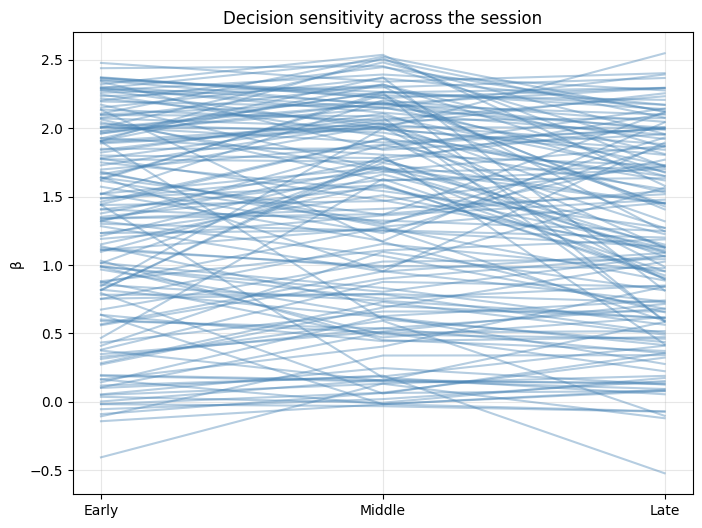

In [ ]:
plt.figure(figsize=(8,6))

for _, row in results_df.iterrows():

    plt.plot(
        ["Early","Middle","Late"],
        [
            row.beta_early,
            row.beta_middle,
            row.beta_late
        ],
        alpha=0.4,
        color="steelblue"
    )

plt.ylabel("β")
plt.title("Decision sensitivity across the session")
plt.grid(alpha=.3)

plt.show()

Each line represents one mouse. This lets us see how individual mice change over the session. Some mice increase in sensitivity, some decrease, and others remain fairly stable, showing substantial individual differences.

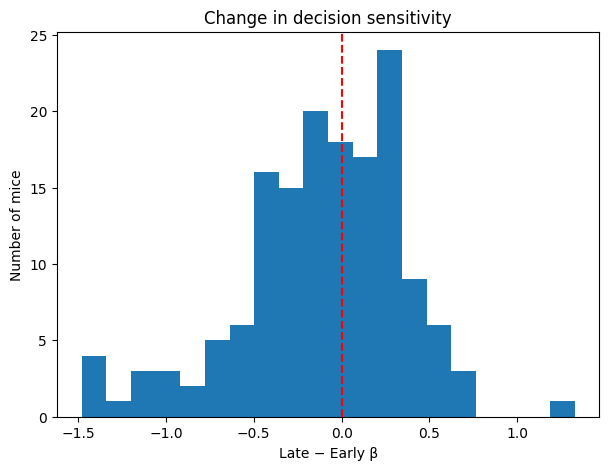

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(
    results_df["delta_beta"],
    bins=20
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Late − Early β")
plt.ylabel("Number of mice")

plt.title("Change in decision sensitivity")

plt.show()

#### Most Δβ values cluster near zero, indicating that most mice maintain relatively stable decision strategies throughout the session. This is consistent with Ashwood et al. (2022), who found that mice tend to remain in the same decision-making state (engaged or biased) due to high self-transition probabilities (0.75–0.98). The few large outliers may represent mice that switched behavioral states during the session.

In [ ]:
from scipy.stats import ttest_rel # imoprt stats

t,p = ttest_rel(
    results_df["beta_early"],
    results_df["beta_late"]
)

print(t,p)

2.828715877029919 0.0053043680742366015


In [ ]:
t,p = ttest_rel(
    results_df["bias_early"],
    results_df["bias_late"]
)

print(t,p)

-0.7033756091763231 0.48289770236547225


/tmp/ipykernel_1782/3769730483.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


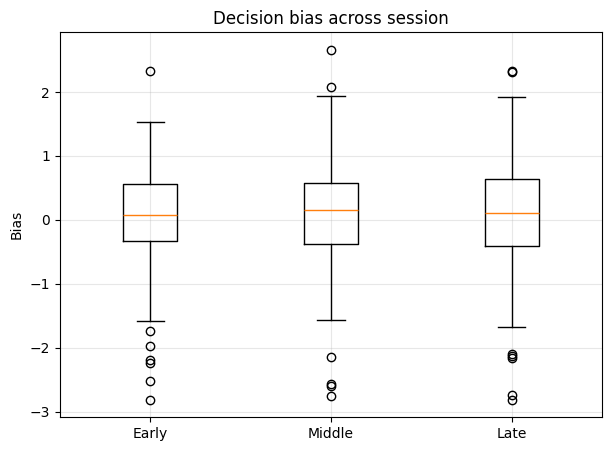

In [ ]:
plt.figure(figsize=(7,5))

plt.boxplot([
    results_df["bias_early"],
    results_df["bias_middle"],
    results_df["bias_late"]
],
labels=["Early","Middle","Late"])

plt.ylabel("Bias")
plt.title("Decision bias across session")

plt.grid(alpha=0.3)

plt.show()

 The Middle section has the highest median β, while the Late section shifts downward. There's also noticeable variability between mice.

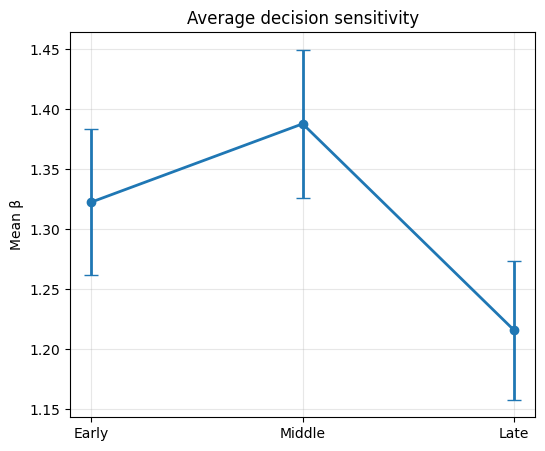

In [ ]:
import numpy as np

means = [
    results_df.beta_early.mean(),
    results_df.beta_middle.mean(),
    results_df.beta_late.mean()
]

sems = [
    results_df.beta_early.sem(),
    results_df.beta_middle.sem(),
    results_df.beta_late.sem()
]

plt.figure(figsize=(6,5))

plt.errorbar(
    ["Early","Middle","Late"],
    means,
    yerr=sems,
    marker="o",
    capsize=5,
    linewidth=2
)

plt.ylabel("Mean β")
plt.title("Average decision sensitivity")

plt.grid(alpha=0.3)

plt.show()

mouse is biased more towards the history of his previous choices rather than relying on contrast

### The late-session decrease in β suggests that mice relied less on the visual stimulus over time. Rather than reflecting simple fatigue, **previous studies suggest that mice may transition from an engaged, stimulus-driven state to a more biased or history-dependent decision-making state.** This interpretation is consistent with Ashwood et al. (2022) and Ortiz et al. (2020), although it remains a plausible explanation rather than a mechanism directly demonstrated by our dataset.

One possible interpretation is that mice begin the session reasonably engaged, become slightly more consistent during the middle of the session, and then lose some sensitivity later, perhaps due to fatigue, reduced attention, or changes in internal state.

/tmp/ipykernel_1782/377464698.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


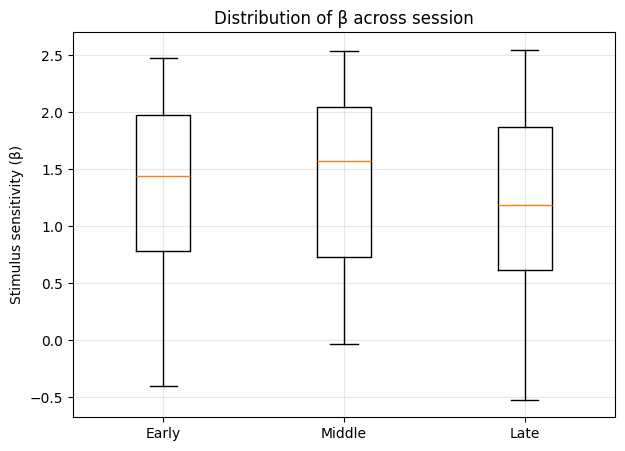

In [ ]:
plt.figure(figsize=(7,5))

plt.boxplot([
    results_df["beta_early"],
    results_df["beta_middle"],
    results_df["beta_late"]
],
labels=["Early","Middle","Late"])

plt.ylabel("Stimulus sensitivity (β)")
plt.title("Distribution of β across session")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
summary = pd.DataFrame({
    "Mean β": [
        results_df.beta_early.mean(),
        results_df.beta_middle.mean(),
        results_df.beta_late.mean()
    ],
    "Std β": [
        results_df.beta_early.std(),
        results_df.beta_middle.std(),
        results_df.beta_late.std()
    ]
}, index=["Early","Middle","Late"])

summary

,Mean β,Std β
Early,1.322603,0.754523
Middle,1.387949,0.764336
Late,1.215740,0.718452


## sensitivity increases slightly in the middle,
then decreases by the end of the session.

## Final Interpretation

- I analyzed 153 mice that each had at least 200 valid trials.
- Each mouse's session was divided into Early, Middle, and Late thirds.
- A logistic regression was fit separately to each section.
- Stimulus sensitivity (β) and decision bias were compared across the session.
- Paired statistical tests quantified whether decision strategy changed systematically over time

In [ ]:
print("===== FINAL RESULTS =====")

print(f"Mice analysed: {len(filtered_mouse_trials)}")
print(f"Minimum trials per mouse: {MIN_TRIALS}")

print("\nBeta t-test")
print(ttest_rel(results_df.beta_early,
                results_df.beta_late))

print("\nBias t-test")
print(ttest_rel(results_df.bias_early,
                results_df.bias_late))

===== FINAL RESULTS =====
Mice analysed: 153
Minimum trials per mouse: 200

Beta t-test
TtestResult(statistic=np.float64(2.828715877029919), pvalue=np.float64(0.0053043680742366015), df=np.int64(152))

Bias t-test
TtestResult(statistic=np.float64(-0.7033756091763231), pvalue=np.float64(0.48289770236547225), df=np.int64(152))


In [ ]:
# Export the complete results dataframe
results_df.to_csv("results_df.csv", index=False)

print(f"Saved {len(results_df)} rows to results_df.csv")

Saved 153 rows to results_df.csv


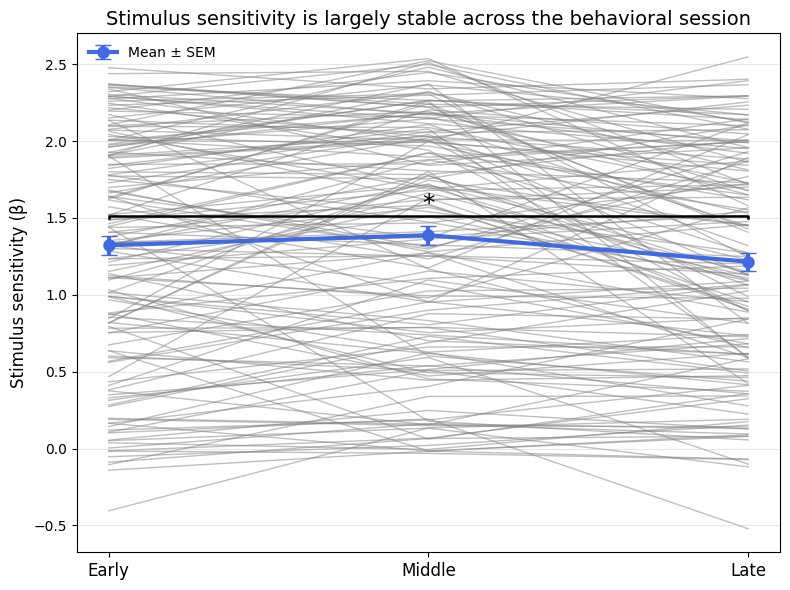

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# -----------------------------
# Individual mouse trajectories
# -----------------------------
plt.figure(figsize=(8,6))

x = np.arange(3)

for _, row in results_df.iterrows():
    plt.plot(
        x,
        [row.beta_early, row.beta_middle, row.beta_late],
        color="gray",
        linewidth=1,
        alpha=0.5,
        zorder=1
    )

# -----------------------------
# Mean ± SEM
# -----------------------------
means = [
    results_df["beta_early"].mean(),
    results_df["beta_middle"].mean(),
    results_df["beta_late"].mean()
]

sems = [
    sem(results_df["beta_early"]),
    sem(results_df["beta_middle"]),
    sem(results_df["beta_late"])
]

plt.errorbar(
    x,
    means,
    yerr=sems,
    fmt='o-',
    color='royalblue',
    linewidth=3,
    markersize=8,
    capsize=6,
    label="Mean ± SEM",
    zorder=3
)

# -----------------------------
# Significance bar
# -----------------------------
y = max(means) + max(sems) + 0.05
h = 0.01

plt.plot([0,0,2,2],[y,y+h,y+h,y], lw=1.8, c='black')
plt.text(
    1,
    y+h+0.005,
    "*",
    ha='center',
    va='bottom',
    fontsize=18
)

# -----------------------------
# Formatting
# -----------------------------
plt.xticks(x, ["Early","Middle","Late"], fontsize=12)
plt.ylabel("Stimulus sensitivity (β)", fontsize=12)
plt.title("Stimulus sensitivity is largely stable across the behavioral session", fontsize=14)

plt.grid(axis="y", alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

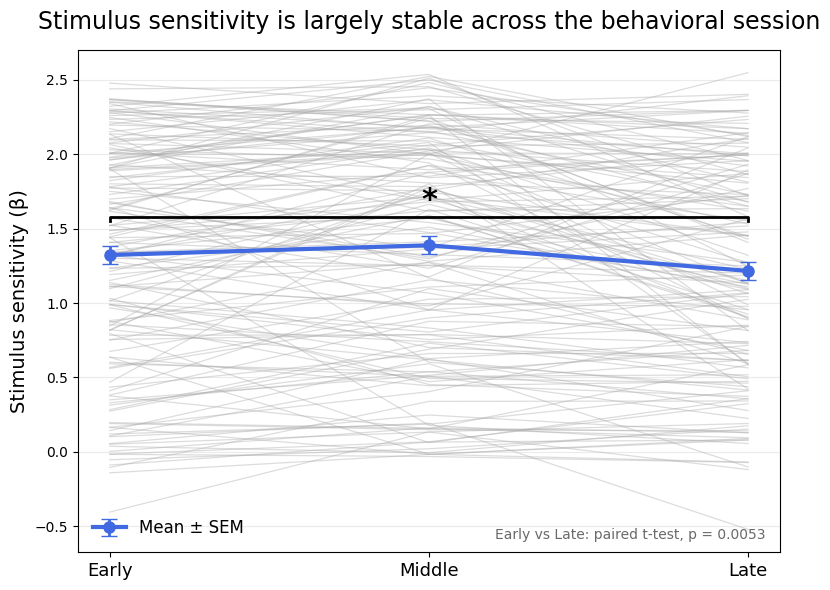

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# -----------------------------
# Data
# -----------------------------
x = np.array([0, 1, 2])
labels = ["Early", "Middle", "Late"]

beta_values = results_df[
    ["beta_early", "beta_middle", "beta_late"]
].values

means = beta_values.mean(axis=0)
sems = sem(beta_values, axis=0)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8,6))

# Individual mice
for row in beta_values:
    ax.plot(
        x,
        row,
        color="darkgray",
        alpha=0.4,
        linewidth=0.9,
        zorder=1
    )

# Mean ± SEM
ax.errorbar(
    x,
    means,
    yerr=sems,
    fmt='o-',
    color='royalblue',
    linewidth=3,
    markersize=8,
    capsize=6,
    elinewidth=2,
    label='Mean ± SEM',
    zorder=5
)

# -----------------------------
# Significance bracket
# -----------------------------
y = max(means + sems) + 0.10
h = 0.03

ax.plot(
    [0, 0, 2, 2],
    [y, y+h, y+h, y],
    color='black',
    linewidth=2
)

ax.text(
    1,
    y+h+0.015,
    "*",
    ha='center',
    va='bottom',
    fontsize=22,
    fontweight='bold'
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13)

ax.set_ylabel("Stimulus sensitivity (β)", fontsize=14)

ax.set_title(
    "Stimulus sensitivity is largely stable across the behavioral session",
    fontsize=17,
    pad=15
)

ax.grid(axis='y', alpha=0.25)

ax.legend(frameon=False, fontsize=12)

# Exact p-value
ax.text(
    0.98,
    0.02,
    "Early vs Late: paired t-test, p = 0.0053",
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=10,
    color='dimgray'
)

plt.tight_layout()
plt.show()